In [1]:
import atlasopenmagic as atom
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file = uproot.open('DAOD_PHYSLITE.38191666._000036.pool.root.1')
tree = file['CollectionTree']

In [3]:
pt = tree["AnalysisPhotonsAuxDyn.pt"].array()
eta = tree["AnalysisPhotonsAuxDyn.eta"].array()
phi = tree["AnalysisPhotonsAuxDyn.phi"].array()
mass = tree["AnalysisPhotonsAuxDyn.m"].array()

ptcone20 = tree["AnalysisPhotonsAuxDyn.ptcone20_CloseByCorr"].array()
topoetcone20 = tree["AnalysisPhotonsAuxDyn.topoetcone20_CloseByCorr"].array()
topoetcone40 = tree["AnalysisPhotonsAuxDyn.topoetcone40_CloseByCorr"].array()

f1 = tree["AnalysisPhotonsAuxDyn.f1"].array()

cleaning = tree["AnalysisPhotonsAuxDyn.DFCommonPhotonsCleaning"].array()
isEMTight = tree["AnalysisPhotonsAuxDyn.DFCommonPhotonsIsEMTight"].array()

OQ = tree["AnalysisPhotonsAuxDyn.OQ"].array()

truthType = tree["AnalysisPhotonsAuxDyn.truthType"].array()
truthOrigin = tree["AnalysisPhotonsAuxDyn.truthOrigin"]. array()

In [4]:
pt_np = ak.flatten(pt).to_numpy()
eta_np = ak.flatten(eta).to_numpy()
phi_np = ak.flatten(phi).to_numpy()
mass_np = ak.flatten(mass).to_numpy()


In [5]:
print(f'Total number of photons in 200,000 events: {len(pt_np):,}')
pt_np

Total number of photons in 200,000 events: 684,598


array([66556.    , 53268.395 ,  2222.0193, ...,  2495.0068,  2511.181 ,
        2217.2075], shape=(684598,), dtype=float32)

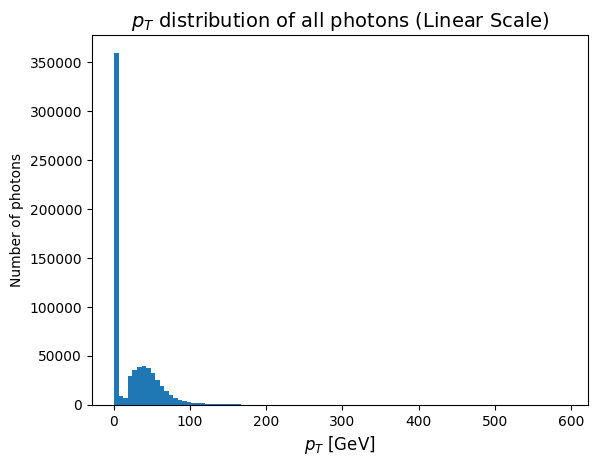

In [6]:
pt_gev = pt_np / 1000  # MeV to GeV

plt.hist(pt_gev, bins=100)
plt.title('$p_T$ distribution of all photons (Linear Scale)', fontsize=14)
plt.xlabel('$p_T$ [GeV]', fontsize=12)
plt.ylabel('Number of photons')
plt.show()

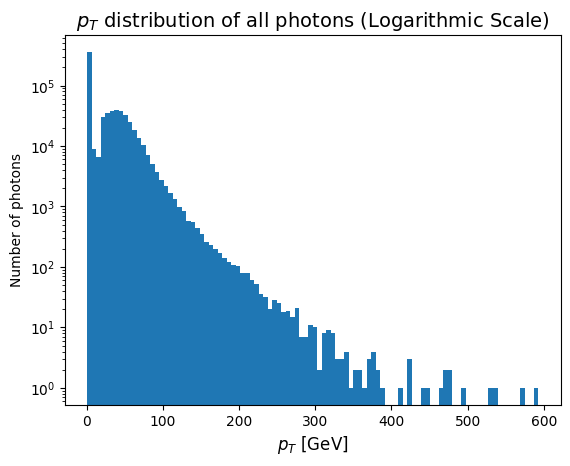

In [7]:
plt.hist(pt_gev, bins=100,)
plt.yscale('log')
plt.title('$p_T$ distribution of all photons (Logarithmic Scale)', fontsize=14)
plt.xlabel('$p_T$ [GeV]', fontsize=12)
plt.ylabel('Number of photons')
plt.show()

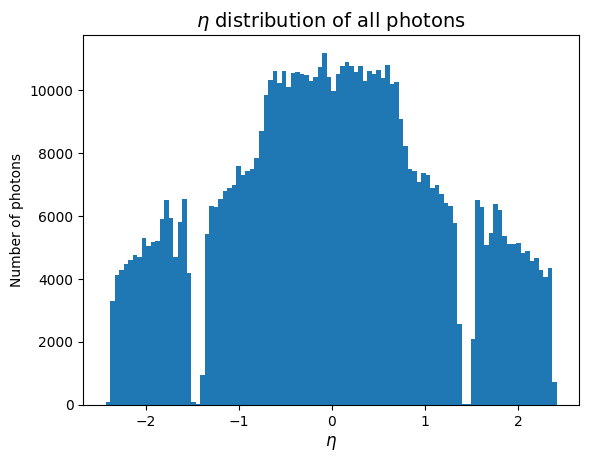

In [8]:
plt.hist(eta_np, bins=100)
plt.title(r'$\eta$ distribution of all photons', fontsize=14)
plt.xlabel(r'$\eta$', fontsize=12)
plt.ylabel('Number of photons')
plt.show()

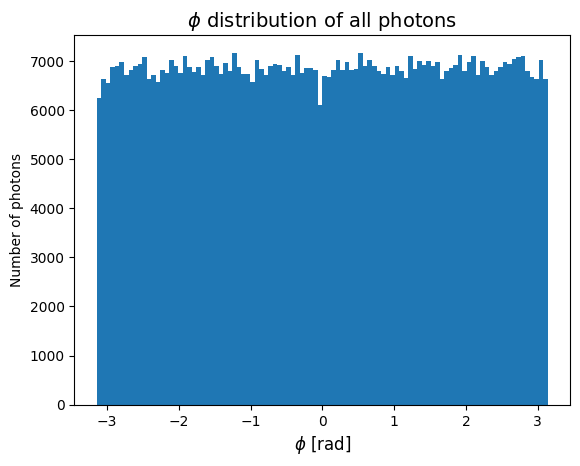

In [9]:
plt.hist(phi_np, bins=100)
plt.title(r'$\phi$ distribution of all photons', fontsize=14)
plt.xlabel(r'$\phi$ [rad]', fontsize=12)
plt.ylabel('Number of photons')
plt.show()

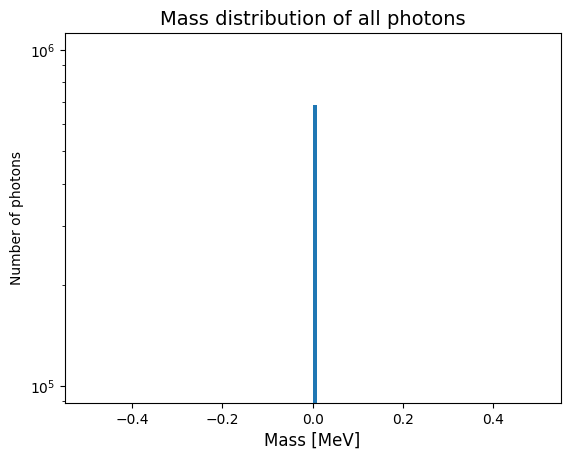

In [10]:
plt.hist(mass_np, bins=100, log=True)
plt.title('Mass distribution of all photons', fontsize=14)
plt.xlabel('Mass [MeV]', fontsize=12)
plt.ylabel('Number of photons')
plt.show()

In [11]:
truthType_np= ak.flatten(truthType).to_numpy()
truthOrigin_np= ak.flatten(truthOrigin).to_numpy()

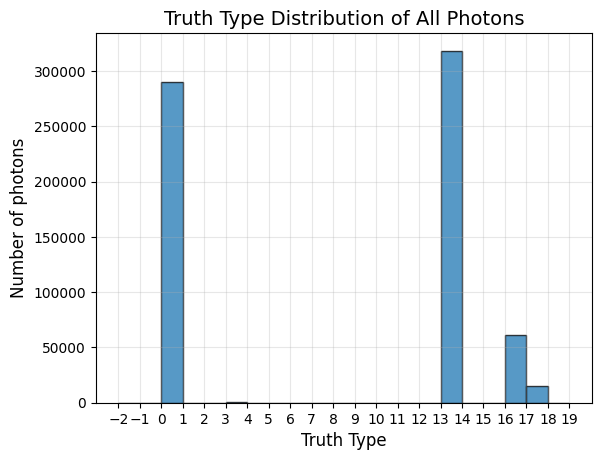

In [12]:
plt.hist(truthType_np, bins=range(-2, 20, 1 ), edgecolor='black', alpha=0.75)
plt.title('Truth Type Distribution of All Photons', fontsize=14)
plt.xlabel('Truth Type', fontsize=12)
plt.ylabel('Number of photons', fontsize=12)
plt.xticks(range(-2, 20, 1))
plt.grid(alpha=0.3)
plt.show()

Enumerations source: https://gitlab.cern.ch/atlas/athena/blob/21.2/PhysicsAnalysis/MCTruthClassifier/MCTruthClassifier/MCTruthClassifierDefs.h

0--> unknown 

13 -->  Unknown Photon 

16 ---> Background Photon 

17 ---> Hadron Background

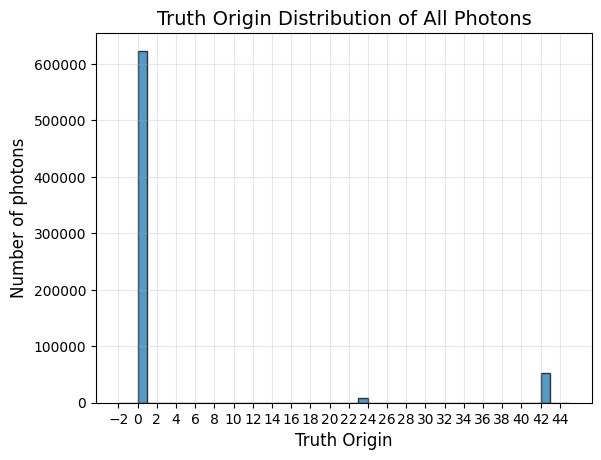

In [13]:
plt.hist(truthOrigin_np, bins=range(-2, 46, 1 ), edgecolor='black', alpha=0.75)
plt.title('Truth Origin Distribution of All Photons', fontsize=14)
plt.xlabel('Truth Origin', fontsize=12)
plt.ylabel('Number of photons', fontsize=12)
plt.xticks(range(-2, 46, 2))
plt.grid(alpha=0.3)
plt.show()

 0 ---> NonDefined (Not classified, could be anything)

 14---> Higgs (From Higgs boson decay)

 23 --> LightMeson

 42 --> piZero (pion bozunumundan gelen foton)

In [14]:
cleaning_np= ak.flatten(cleaning).to_numpy()
isEMTight_np= ak.flatten(isEMTight).to_numpy()
OQ_np= ak.flatten(OQ).to_numpy()

STATISTICS:

In [15]:
print(f"Total photons: {len(cleaning_np):,}\n")

print("--- DFCommonPhotonsCleaning ---")
print(f"Passed): {np.sum(cleaning_np == 1):,} ({100*np.sum(cleaning_np==1)/len(cleaning_np):.2f}%)")
print(f"Failed:  {np.sum(cleaning_np != 1):,} ({100*np.sum(cleaning_np!=1)/len(cleaning_np):.2f}%)")

print("\n--- DFCommonPhotonsIsEMTight ---")
print(f"Passed): {np.sum(isEMTight_np == 1):,} ({100*np.sum(isEMTight_np==1)/len(isEMTight_np):.2f}%)")
print(f"Failed:  {np.sum(isEMTight_np != 1):,} ({100*np.sum(isEMTight_np!=1)/len(isEMTight_np):.2f}%)")

print("\n--- Object Quality (OQ) ---")
print(f"Good OQ :  {np.sum(OQ_np == 0):,} ({100*np.sum(OQ_np==0)/len(OQ_np):.2f}%)")
print(f"Bad OQ :   {np.sum(OQ_np != 0):,} ({100*np.sum(OQ_np!=0)/len(OQ_np):.2f}%)")

Total photons: 684,598

--- DFCommonPhotonsCleaning ---
Passed): 684,598 (100.00%)
Failed:  0 (0.00%)

--- DFCommonPhotonsIsEMTight ---
Passed): 343,753 (50.21%)
Failed:  340,845 (49.79%)

--- Object Quality (OQ) ---
Good OQ :  364,777 (53.28%)
Bad OQ :   319,821 (46.72%)


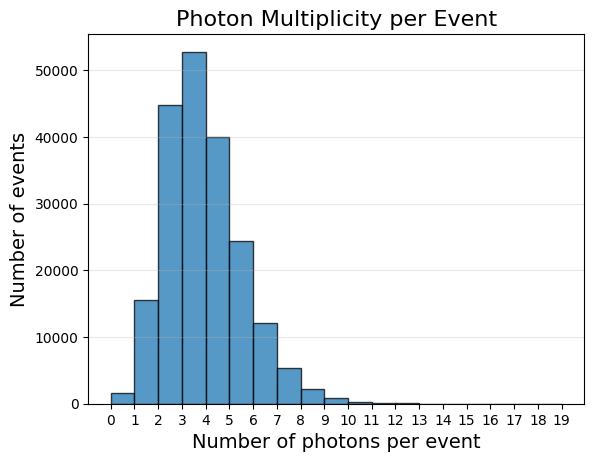

In [16]:
photons_per_event = ak.num(pt) # ak.num --->  It counts how many elements there are in each "row" (event) of the jagged array.
plt. hist(photons_per_event, bins=range(0, 20), edgecolor='black', alpha=0.75)
plt.xlabel('Number of photons per event', fontsize=14)
plt.ylabel('Number of events', fontsize=14)
plt.title('Photon Multiplicity per Event', fontsize=16)
plt. xticks(range(0, 20, 1))
plt.grid(alpha=0.3, axis='y')
plt.show()

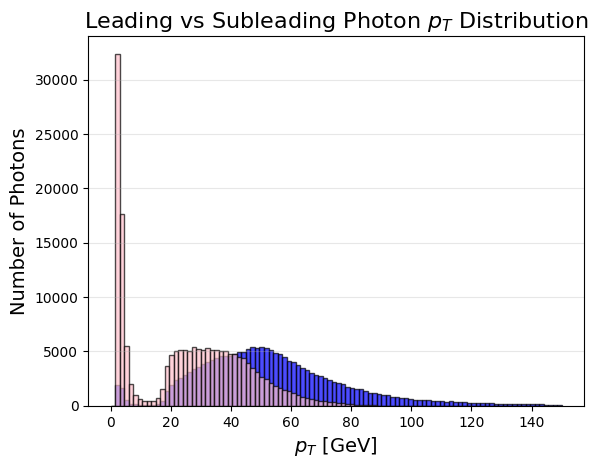

In [17]:
# Leading (highest-pT) ve Subleading (second highest-pT)
event_with_2plus_photons = pt[ak.num(pt) >= 2]
leading_pt = event_with_2plus_photons[:, 0] /1000
subleading_pt = event_with_2plus_photons[:, 1] / 1000

plt.hist(leading_pt, bins=100, range=(0,150), alpha=0.7, label='Leading Photon pT', color='blue', edgecolor='black')
plt.hist(subleading_pt, bins=100, range=(0,150), alpha=0.7, label='Subleading Photon pT', color='pink', edgecolor='black')
plt.xlabel('$p_T$ [GeV]', fontsize=14)
plt.ylabel('Number of Photons', fontsize=14)
plt.title('Leading vs Subleading Photon $p_T$ Distribution', fontsize=16)
plt. grid(alpha=0.3, axis='y')
plt.show()